# TabPFN Hands-On-Demo

**Welcome to this enhanced and educational walkthrough of TabPFN!**

TabPFN is a novel machine learning model that is exceptionally fast and requires no hyperparameter tuning. It is particularly powerful for tabular data, which is a common data format in many real-world applications. This notebook will not only demonstrate how to use TabPFN but also provide clear explanations of the underlying concepts.

**What you will learn:**

* What TabPFN is and why it's a game-changer for tabular data.
* How to set up and run TabPFN on your local machine or using the client API.
* How to use TabPFN for both classification and regression tasks.
* A comparison of TabPFN's performance against other popular models like XGBoost and RandomForest.
* Advanced features of TabPFN, including handling text data, unsupervised learning, and model interpretability.

Let's get started!



## Table of Contents

1.  [Installation](#installation)
2.  [Backend Selection](#backend-selection)
3.  [**Classification with TabPFN**](#classification)
4.  [**Regression with TabPFN**](#regression)
5.  [Handling Text Data](#text-data)
6.  [Unsupervised Learning with TabPFN](#unsupervised-learning)
   - Data Imputation
   - Anomaly Detection
   - Clustering Applications
7.  [Model Interpretability](#interpretability)
   - Feature Importance Analysis
   - Explaining Predictions with SHAP
   - Extracting and Visualizing Embeddings
8.  [Predictive Behavior](#behavior)
9.  [**Time Series Prediction**](#timeseries)



# Installation [Running this cell required!] <a name="installation"></a>

First, we need to install the necessary libraries. This includes TabPFN itself, as well as other libraries for data manipulation and baseline model comparisons. If you are asked to restart the runtime after installation, please do so.


In [3]:
## Base library Installation
# Install Baselines for model comparison
!uv pip install catboost xgboost

# Install the datasets library for loading example data
!uv pip install datasets

# Install rich for better and more readable printing
!uv pip install rich


## TabPFN Installation optimized for Google Colab
# Install the TabPFN Client library
!uv pip install tabpfn-client

# Install tabpfn from source
# Clone the repository: shallow for speedup
!git clone --depth 1 https://github.com/PriorLabs/tabpfn

# Speeding up installation in this notebook:
# Remove torch dependency as it is already installed on colab (do not run this in your local setup)
!sed -i "/torch/d" tabpfn/pyproject.toml

# Step 3: Install using the correct directory name 'tabpfn'
!uv pip install -e "tabpfn"

# Install TabPFN extensions for additional functionalities
!git clone https://github.com/PriorLabs/tabpfn-extensions

# Speeding up installation in this notebook:
# Remove torch dependency as it is already installed on colab (do not run this in your local setup)
!sed -i "/torch/d" tabpfn-extensions/pyproject.toml

!uv pip install -e tabpfn-extensions[all]

Using Python 3.11.13 environment at: /usr
Audited 2 packages in 78ms
Using Python 3.11.13 environment at: /usr
Audited 1 package in 74ms
Using Python 3.11.13 environment at: /usr
Audited 1 package in 69ms
Using Python 3.11.13 environment at: /usr
Audited 1 package in 75ms
fatal: destination path 'tabpfn' already exists and is not an empty directory.
Using Python 3.11.13 environment at: /usr
Resolved 32 packages in 27ms
   Building tabpfn @ file:///content/tabpfn
   Building tabpfn @ file:///content/tabpfn
   Building tabpfn @ file:///content/tabpfn
   Building tabpfn @ file:///content/tabpfn
      Built tabpfn @ file:///content/tabpfn
Prepared 1 package in 694ms
Uninstalled 1 package in 0.37ms
Installed 1 package in 0.87ms
 ~ tabpfn==2.1.2 (from file:///content/tabpfn)
fatal: destination path 'tabpfn-extensions' already exists and is not an empty directory.
Using Python 3.11.13 environment at: /usr
Resolved 65 packages in 59ms
   Building tabpfn-extensions @ file:///content/tabpfn-exte

***Note: remember to restart the runtime after the installation.***

# Necessary Imports for the Notebook [Running this cell required!]

Now that the libraries are installed, let's import all the necessary modules for this notebook.




In [1]:
# Standard Library Imports

# TabPFN and Extensions

try:
    from tabpfn import TabPFNClassifier, TabPFNRegressor
    from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import (
        AutoTabPFNClassifier,
    )
except ImportError:
    raise ImportError(
        "Warning: Could not import TabPFN / TabPFN extensions. Please run installation above and restart the session afterwards (Runtime > Restart Session)."
    )

# Data Science & Visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Other ML Models
from catboost import CatBoostClassifier, CatBoostRegressor

# Notebook UI/Display
from IPython.display import Markdown, display
from rich.console import Console
from rich.panel import Panel
from rich.prompt import Prompt
from rich.rule import Rule
from sklearn.compose import make_column_selector, make_column_transformer

# Scikit-Learn: Data & Preprocessing
from sklearn.datasets import fetch_openml, load_breast_cancer

# Scikit-Learn: Models
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, roc_auc_score
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from xgboost import XGBClassifier, XGBRegressor

# This transformer will be used to handle categorical features for the baseline models
column_transformer = make_column_transformer(
    (
        OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        make_column_selector(dtype_include=["object", "category"]),
    ),
    remainder="passthrough",
)

# Backend Selection [Running this cell required!] <a name="backend-selection"></a>


TabPFN can be run in two ways: locally on your machine (if you have a GPU) or by using the TabPFN client, which sends the data to a server for computation.
In your project you would either use the local version (which requires a GPU) with :
```python
# Simple import for TabPFN
from tabpfn import TabPFNClassifier

# Now you can use it like any other sklearn classifier
# model = TabPFNClassifier()
print("TabPFNClassifier imported successfully.")
```

or the **client** API (which uses a remote server):

```python
# Simple import for TabPFN
from tabpfn_client import TabPFNClassifier

# Now you can use it like any other sklearn classifier
# model = TabPFNClassifier()
print("TabPFNClassifier imported successfully.")
```


For demonstration purposes, the cell below provides an interactive way to switch between those:


In [2]:
console = Console()

console.print(Panel.fit("[bold magenta]TabPFN Demo: Backend Selection[/bold magenta]"))
console.print("\nThis script can run TabPFN using one of two backends:")
console.print("  [bold]1. local:[/bold] Uses a local GPU (NVIDIA). Requires CUDA.")
console.print(
    "  [bold]2. client:[/bold] Uses the TabPFN API. Requires an internet connection and a free account."
)

backend = Prompt.ask(
    "\n[bold]Choose your backend[/bold] - If not field to enter is shown restart the cell.",
    choices=["client", "local"],
    default="client",
)

console.print(
    f"\n✅ You have selected the '[bold green]{backend}[/bold green]' backend."
)

console.print(Rule(f"[bold]Setting up [cyan]{backend}[/cyan] backend[/bold]"))

if backend == "local":
    console.print("Attempting local backend setup...")
    import torch

    if not torch.cuda.is_available():
        console.print(
            "[bold red]Error:[/bold red] GPU device not found. For fast training, please enable GPU.",
            style="red",
        )
        console.print(
            "In Colab: Go to [bold]Runtime -> Change runtime type -> Hardware accelerator -> GPU.[/bold]",
            style="yellow",
        )
        raise SystemError("GPU device not found.")
    console.print(
        "[bold green]✅ GPU is available.[/bold green] Importing local TabPFN library..."
    )
    from tabpfn import TabPFNClassifier, TabPFNRegressor

    console.print("[bold green]✅ TabPFN (local) imported successfully.[/bold green]")
elif backend == "client":
    console.print("Attempting client backend setup...")
    console.print("Importing TabPFN client library...")
    from tabpfn_client import TabPFNClassifier, TabPFNRegressor, init

    init()
    console.print("[bold green]✅ TabPFN (client) initialized.[/bold green]")

╭────────────────────────────────╮
│ TabPFN Demo: Backend Selection │
╰────────────────────────────────╯

This script can run TabPFN using one of two backends:

1. local: Uses a local GPU (NVIDIA). Requires CUDA.

2. client: Uses the TabPFN API. Requires an internet connection and a free account.

Choose your backend - If not field to enter is shown restart the cell. [client/local] (client):

...

──────────────────────────────────────────── Setting up client backend ────────────────────────────────────────────

Attempting client backend setup...

Importing TabPFN client library...

  Welcome to TabPFN!

  TabPFN is still under active development, and we are working hard to make it better.
  Please bear with us if you encounter any issues.


Opening browser for login. Please complete the login/registration process in your browser and return here.


Could not open browser automatically. Falling back to command-line login...

  Please choose one of the following options:
  (1) Create a TabPFN account
  (2) Login to your TabPFN account

  Please enter your choice: TabPFN account
  Invalid choice, please enter '1' or '2': 1

  Please refer to our terms and conditions at: https://www.priorlabs.ai/terms By using TabPFN, you agree to the following terms and conditions:
  Do you agree to the above terms and conditions? (y/n): y
  Please enter your email: precious.ajilore04@gmail.com

  Password requirements (minimum):
  . Length(8)
  . Uppercase(1)
  . Numbers(1)
  . Special(1)

  Please enter your password: ··········
  Please confirm your password: ··········
  Do you a

✅ TabPFN (client) initialized.

# Classification with TabPFN <a name="classification"></a>

Now, let's dive into a practical example of using TabPFN for a classification task. We will use the well-known Parkinson's Disease dataset. The goal is to predict the presence of Parkinson's disease based on various voice measurements.

We will compare TabPFN's performance against other popular machine learning models: RandomForest, XGBoost, and CatBoost. The performance metric we will use is the [ROC AUC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html) score.


In [11]:
# Parkinson's Disease dataset: Predict Parkinson's disease presence
# Features: Voice measurements (e.g., frequency, amplitude)
# Samples: 195 cases
df = load_breast_cancer(as_frame=True)

X, y = df.data, df.target

# Print dataset description
display(Markdown(df["DESCR"]))

display(X)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - class:
            - WDBC-Malignant
            - WDBC-Benign

:Summary Statistics:

===================================== ====== ======
                                        Min    Max
===================================== ====== ======
radius (mean):                        6.981  28.11
texture (mean):                       9.71   39.28
perimeter (mean):                     43.79  188.5
area (mean):                          143.5  2501.0
smoothness (mean):                    0.053  0.163
compactness (mean):                   0.019  0.345
concavity (mean):                     0.0    0.427
concave points (mean):                0.0    0.201
symmetry (mean):                      0.106  0.304
fractal dimension (mean):             0.05   0.097
radius (standard error):              0.112  2.873
texture (standard error):             0.36   4.885
perimeter (standard error):           0.757  21.98
area (standard error):                6.802  542.2
smoothness (standard error):          0.002  0.031
compactness (standard error):         0.002  0.135
concavity (standard error):           0.0    0.396
concave points (standard error):      0.0    0.053
symmetry (standard error):            0.008  0.079
fractal dimension (standard error):   0.001  0.03
radius (worst):                       7.93   36.04
texture (worst):                      12.02  49.54
perimeter (worst):                    50.41  251.2
area (worst):                         185.2  4254.0
smoothness (worst):                   0.071  0.223
compactness (worst):                  0.027  1.058
concavity (worst):                    0.0    1.252
concave points (worst):               0.0    0.291
symmetry (worst):                     0.156  0.664
fractal dimension (worst):            0.055  0.208
===================================== ====== ======

:Missing Attribute Values: None

:Class Distribution: 212 - Malignant, 357 - Benign

:Creator:  Dr. William H. Wolberg, W. Nick Street, Olvi L. Mangasarian

:Donor: Nick Street

:Date: November, 1995

This is a copy of UCI ML Breast Cancer Wisconsin (Diagnostic) datasets.
https://goo.gl/U2Uwz2

Features are computed from a digitized image of a fine needle
aspirate (FNA) of a breast mass.  They describe
characteristics of the cell nuclei present in the image.

Separating plane described above was obtained using
Multisurface Method-Tree (MSM-T) [K. P. Bennett, "Decision Tree
Construction Via Linear Programming." Proceedings of the 4th
Midwest Artificial Intelligence and Cognitive Science Society,
pp. 97-101, 1992], a classification method which uses linear
programming to construct a decision tree.  Relevant features
were selected using an exhaustive search in the space of 1-4
features and 1-3 separating planes.

The actual linear program used to obtain the separating plane
in the 3-dimensional space is that described in:
[K. P. Bennett and O. L. Mangasarian: "Robust Linear
Programming Discrimination of Two Linearly Inseparable Sets",
Optimization Methods and Software 1, 1992, 23-34].

This database is also available through the UW CS ftp server:

ftp ftp.cs.wisc.edu
cd math-prog/cpo-dataset/machine-learn/WDBC/

.. dropdown:: References

  - W.N. Street, W.H. Wolberg and O.L. Mangasarian. Nuclear feature extraction
    for breast tumor diagnosis. IS&T/SPIE 1993 International Symposium on
    Electronic Imaging: Science and Technology, volume 1905, pages 861-870,
    San Jose, CA, 1993.
  - O.L. Mangasarian, W.N. Street and W.H. Wolberg. Breast cancer diagnosis and
    prognosis via linear programming. Operations Research, 43(4), pages 570-577,
    July-August 1995.
  - W.H. Wolberg, W.N. Street, and O.L. Mangasarian. Machine learning techniques
    to diagnose breast cancer from fine-needle aspirates. Cancer Letters 77 (1994)
    163-171.


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
# Alternative datasets (commented for reference):

# German Credit Fraud (ID: 31)
# Samples: 1,000
# Features: 20 (account info, credit history, employment)
# Target: Good/Bad credit risk
# df = fetch_openml(data_id=31)

# Cholesterol dataset: Predict cholesterol levels
# Features: Patient characteristics, medical measurements
# Samples: 303 patients
# Target: Cholesterol levels in mg/dl
# df = fetch_openml('cholesterol', version=2, as_frame=True)

# Heart Disease dataset (Statlog): Predict presence of heart disease
# Features: Clinical and test measurements
# Samples: 270 patients
# Target: Binary heart disease diagnosis
# df = fetch_openml("heart-statlog", version=1)

# Diabetes dataset: Predict diabetes presence
# Features: Medical measurements, patient history
# Samples: 768 patients
# Target: Binary diabetes diagnosis
# df = fetch_openml("diabetes", version=1)

In [12]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Train and evaluate the TabPFN classifier
tabpfn_classifier = TabPFNClassifier(random_state=42)
tabpfn_classifier.fit(X_train, y_train)
y_pred_proba = tabpfn_classifier.predict_proba(X_test)

# Calculate the ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f"TabPFN ROC AUC Score: {roc_auc:.4f}")

Processing: 100%|██████████| [00:01<00:00]


TabPFN ROC AUC Score: 0.9954


### Comparing TabPFN with Other Classifiers

To get a better sense of TabPFN's performance, let's compare it with other popular classification models using cross-validation. This will give us a more robust estimate of each model's performance.


Processing: 100%|██████████| [00:01<00:00]
Processing: 100%|██████████| [00:01<00:00]
Processing: 100%|██████████| [00:01<00:00]
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   16.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   20.8s finished


Text(0.5, 1.0, 'Model Comparison - 3-fold Cross-validation')

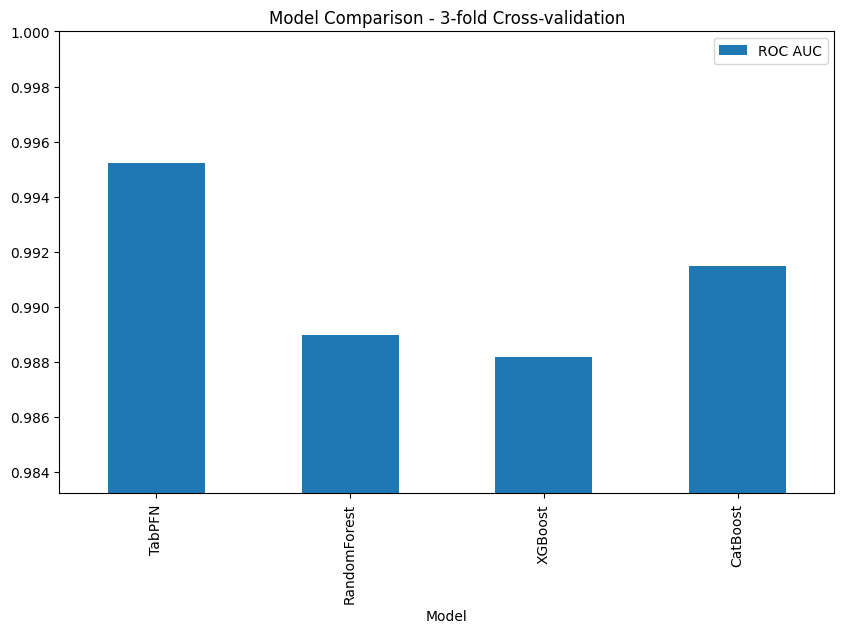

In [13]:
# Compare different machine learning models by training each one multiple times
# on different parts of the data and averaging their performance scores for a
# more reliable performance estimate

# Encode target labels to classes for baselines
le = LabelEncoder()
y = le.fit_transform(y)

# Define models
models = [
    ("TabPFN", TabPFNClassifier(random_state=42)),
    (
        "RandomForest",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            RandomForestClassifier(random_state=42),
        ),
    ),
    (
        "XGBoost",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            XGBClassifier(random_state=42),
        ),
    ),
    (
        "CatBoost",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            CatBoostClassifier(random_state=42, verbose=0),
        ),
    ),
]

# Calculate scores
n_splits = 3
cv = StratifiedKFold(n_splits=n_splits, random_state=42, shuffle=True)
scoring = "roc_auc_ovr" if len(np.unique(y)) > 2 else "roc_auc"
scores = {
    name: cross_val_score(
        model, X, y, cv=cv, scoring=scoring, n_jobs=1, verbose=1
    )
    for name, model in models
}

# Plot results
df = pd.DataFrame([(k, v.mean()) for (k, v) in scores.items()], columns=["Model", "ROC AUC"])
ax = df.plot(x="Model", y="ROC AUC", kind="bar", figsize=(10, 6))
ax.set_ylim(df["ROC AUC"].min() * 0.995, min(1.0, df["ROC AUC"].max() * 1.005))
ax.set_title(f"Model Comparison - {n_splits}-fold Cross-validation")

### Auto TabPFN Classifier (Best Predictice Performance)
The AutoTabPFN classifier enhances the standard TabPFN by employing a post-hoc ensemble technique, which is similar to stacking. This method combines predictions from multiple models to improve overall predictive performance. In this section, we'll demonstrate how to use the AutoTabPFN classifier and compare its performance against the standard TabPFN and other baseline models.

In [14]:
from tabpfn_extensions import AutoTabPFNClassifier

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Train and evaluate the TabPFN classifier
tabpfn_classifier = AutoTabPFNClassifier(
    random_state=42,
    eval_metric="roc_auc", # which metric are we optimizing?
    max_time=60 # maximum runtime 60 seconds
)
tabpfn_classifier.fit(X_train, y_train)
y_pred_proba = tabpfn_classifier.predict_proba(X_test)

# Calculate the ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f"TabPFN ROC AUC Score: {roc_auc:.4f}")

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.11.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Sun Mar 30 16:01:29 UTC 2025
CPU Count:          2
Memory Avail:       9.93 GB / 12.67 GB (78.3%)
Disk Space Avail:   73.52 GB / 112.64 GB (65.3%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme' : New in v1.4: Massively better than 'best' on datasets <30000 samples by using new models meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra, and TabM. Absolute best accuracy. Requires a GPU. Recommended 64 GB CPU memory and 32+ GB GPU memory.
	presets='best'    : Maximize accuracy. Recommended for most users. Use in c

tabpfn-v2-classifier-vutqq28w.ckpt:   0%|          | 0.00/12.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

	Time limit exceeded... Skipping TabPFNv2_BAG_L1.
Fitting model: TabPFNv2_2_BAG_L1 ... Training model for up to 52.65s of the 52.65s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=1, gpus=1)


tabpfn-v2-classifier-od3j1g5m.ckpt:   0%|          | 0.00/29.0M [00:00<?, ?B/s]

...

	Time limit exceeded... Skipping TabPFNv2_8_BAG_L1.
Fitting model: TabPFNv2_9_BAG_L1 ... Training model for up to 3.97s of the 3.96s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=1, gpus=1)
	Time limit exceeded... Skipping TabPFNv2_9_BAG_L1.
Fitting model: TabPFNv2_10_BAG_L1 ... Training model for up to 2.95s of the 2.94s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=1, gpus=1)
	Time limit exceeded... Skipping TabPFNv2_10_BAG_L1.
Fitting model: TabPFNv2_11_BAG_L1 ... Training model for up to 1.88s of the 1.87s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=1, gpus=1)
	Time limit exceeded... Skipping TabPFNv2_11_BAG_L1.
Fitting model: TabPFNv2_12_BAG_L1 ... Training model for up to 1.00s of the 1.00s of remaining time.
	Fitting 8 child models (S1F1 - S1F8

tabpfn-v2-classifier-znskzxi4.ckpt:   0%|          | 0.00/12.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

	Time limit exceeded... Skipping TabPFNv2_12_BAG_L1.
Fitting model: WeightedEnsemble_L2 ... Training model for up to 59.94s of the -1.63s of remaining time.
	Ensemble Weights: {'TabPFNv2_6_BAG_L1': 1.0}
	0.9969	 = Validation score   (roc_auc)
	0.0s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 61.65s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 116.8 rows/s (455 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/content/TabPFNModels/m-20250809_103727")


TabPFN ROC AUC Score: 0.9964


# Regression with TabPFN <a name="regression"></a>

Next, we'll explore how to use TabPFN for regression tasks. We will use the Boston Housing dataset, where the goal is to predict the median value of owner-occupied homes.

We will measure performance using the [Root Mean Squared Error](https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.root_mean_squared_error.html), and again, we will compare TabPFN with other popular regression models.

In [16]:
# Load the Boston Housing dataset
df_boston = fetch_openml(data_id=44973, as_frame=True)
X, y = df_boston.data, df_boston.target

# Display the dataset description and data
display(Markdown("### Grid Stability Dataset"))
display(Markdown(df_boston["DESCR"]))
display(X.head())

### Grid Stability Dataset

**Data Description**

The local stability analysis of the 4-node star system (electricity producer is in the center) implementing Decentral Smart Grid Control concept was performed.

This dataset contains simulations regarding electrical grid stability. The model is composed of a generator model and an economic model.

The analysis is performed for different sets of input values. Several input values are kept the same: averaging time - 2s, coupling strength - 8s^-2, damping - 0.1s^-1.

The goal is to estimate the stability of the system.

**Attribute Description**

14 features describing the system:

1. *tau[1-4]* - reaction time of participant (real from the range [0.5,10]s), tau1 - value for electricity producer
2. *p[1-4]* - nominal power consumed(negative) / produced(positive)(real). For consumers from the range [-0.5,-2]s^-2; p1 = abs(p2 + p3 + p4)
3. *g[1-4]* - coefficient (gamma) proportional to price elasticity (real from the range [0.05,1]s^-1), g1 - the value for electricity producer
4. *stab* - the maximal real part of the characteristic equation root (if positive - the system is linearly unstable), target feature
5. *stabf* - the stability label of the system (categorical: stable/unstable), alternate target feature for a classification task

Downloaded from openml.org.

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923


In [ ]:
# Alternative datasets (commented for reference):

# Liver Disorders dataset
# Classification task: Predict liver disorder presence
# Features: Blood test results, alcohol consumption
# Samples: 345 patients
# Target: Binary liver disorder diagnosis
# df = fetch_openml("liver-disorders", version=1)

# Grid Stability dataset
# Regression task: Predict electrical grid stability
# Features: Power system measurements, grid parameters
# Samples: 10,000 simulations
# Target: Grid stability score
# df = fetch_openml(data_id=44973, as_frame=True)

# Concrete Compressive Strength dataset
# Regression task: Predict concrete strength
# Features: Concrete components (cement, water, aggregates)
# Samples: 1,030 concrete samples
# Target: Compressive strength in MPa
# df = fetch_openml(data_id=44959, as_frame=True)

In [17]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

# Train and evaluate the TabPFN regressor
tabpfn_regressor = TabPFNRegressor(random_state=42)
tabpfn_regressor.fit(X_train, y_train)
y_pred = tabpfn_regressor.predict(X_test)

# Calculate the Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"TabPFN RMSE: {rmse:.4f}")

Processing: 100%|██████████| [00:11<00:00]

TabPFN RMSE: 0.0058


### Auto TabPFN Regressor (Best Predictice Performance)
The AutoTabPFN regressor enhances the standard TabPFN by employing a post-hoc ensemble technique, which is similar to stacking. This method combines predictions from multiple models to improve overall predictive performance. In this section, we'll demonstrate how to use the AutoTabPFN regressor and compare its performance against the standard TabPFN and other baseline models.

In [19]:
from tabpfn_extensions import AutoTabPFNRegressor

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

# Train and evaluate the TabPFN regressor
tabpfn_regressor = AutoTabPFNRegressor(random_state=42,
                                       eval_metric="rmse", # which metric are we optimizing?
                                       max_time=60 # maximum runtime 60 seconds
                                       )
tabpfn_regressor.fit(X_train, y_train)
y_pred = tabpfn_regressor.predict(X_test)

# Calculate the Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"TabPFN RMSE: {rmse:.4f}")

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.11.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Sun Mar 30 16:01:29 UTC 2025
CPU Count:          2
Memory Avail:       8.76 GB / 12.67 GB (69.1%)
Disk Space Avail:   72.94 GB / 112.64 GB (64.8%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme' : New in v1.4: Massively better than 'best' on datasets <30000 samples by using new models meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra, and TabM. Absolute best accuracy. Requires a GPU. Recommended 64 GB CPU memory and 32+ GB GPU memory.
	presets='best'    : Maximize accuracy. Recommended for most users. Use in c

TabPFN RMSE: 0.0667


### Comparing TabPFN with Other Regressors

Now, let's see how TabPFN's regression performance stacks up against other models using cross-validation.


Processing: 100%|██████████| [00:11<00:00]
Processing: 100%|██████████| [00:11<00:00]
Processing: 100%|██████████| [00:11<00:00]
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   50.7s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   28.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    1.4s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   12.5s finished


Text(0.5, 1.0, 'Model Comparison - 3-fold Cross-validation \n (Variance Explained - Larger is better)')

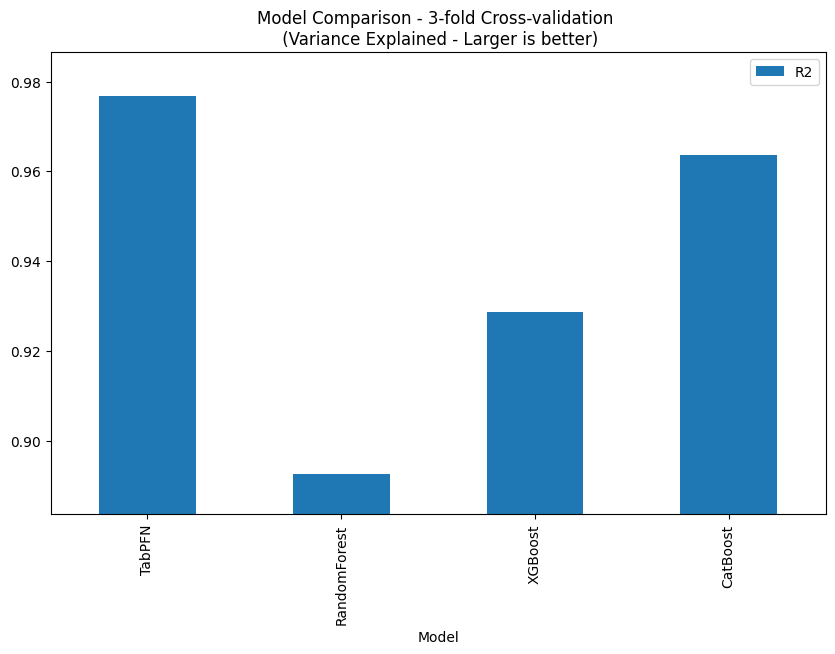

In [20]:
# Compare different machine learning models by training each one multiple times
# on different parts of the data and averaging their performance scores for a
# more reliable performance estimate

# Define models
models = [
    ("TabPFN", TabPFNRegressor(random_state=42)),
    (
        "RandomForest",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            RandomForestRegressor(random_state=42),
        ),
    ),
    (
        "XGBoost",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            XGBRegressor(random_state=42),
        ),
    ),
    (
        "CatBoost",
        make_pipeline(
            column_transformer,  # string data needs to be encoded for model
            CatBoostRegressor(random_state=42, verbose=0),
        ),
    ),
]

# Calculate scores
scoring = "r2"
n_splits = 3
cv = KFold(n_splits=n_splits, random_state=42, shuffle=True)
scores = {
    name: cross_val_score(
        model, X, y, cv=cv, scoring=scoring, n_jobs=1, verbose=1
    )
    for name, model in models
}


# Plot results
df = pd.DataFrame([(k, v.mean()) for (k, v) in scores.items()], columns=["Model", "R2"])
ax = df.plot(x="Model", y="R2", kind="bar", figsize=(10, 6))
ax.set_ylim(df["R2"].min() * 0.99, df["R2"].max() * 1.01)
ax.set_title(
    f"Model Comparison - {n_splits}-fold Cross-validation \n (Variance Explained - Larger is better)"
)

# Handling Text Data <a name="text-data"></a>

A powerful feature of the TabPFN server is its ability to handle text data directly, without the need for manual feature engineering. This simplifies the process of working with datasets that contain a mix of numerical and textual features.

**Note:** This feature is only available when using the 'client' backend.

In [21]:
if backend != "client":
    console.print(
        Panel(
            "[bold yellow]Text data can only be processed through the TabPFN server. Please restart the notebook and select the 'client' backend to run this section.[/bold yellow]",
            title="[bold yellow]Warning",
            border_style="yellow",
        )
    )
else:
    # We will use gdown to download the dataset
    !gdown --fuzzy "17bJekFGIAxbrdcBeBIvcyZjneweY581E"

    # Load the clothing review dataset
    # We restrict to 500 rows to make the example faster
    df_text = pd.read_csv("cloth.csv", index_col=0).dropna()[:500]

    # Define features and target
    y_text = df_text["Rating"]
    X_text = df_text.drop(columns=["Rating"])

    print("Text dataset loaded successfully!")
    display(X_text.head())

Downloading...
From: https://drive.google.com/uc?id=17bJekFGIAxbrdcBeBIvcyZjneweY581E
To: /content/cloth.csv
100% 8.48M/8.48M [00:00<00:00, 19.7MB/s]
Text dataset loaded successfully!


,Clothing ID,Age,Title,Review Text,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,1,6,General,Tops,Blouses
5,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",0,4,General,Dresses,Dresses
6,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,1,General Petite,Tops,Knits


### Comparing Text Handling

Now, let's compare how TabPFN handles text natively versus how a baseline model like RandomForest needs a specific text processing pipeline.

For baselines, we will create a pipeline that converts strings to ordinal features.

For TabPFN, we simply pass the raw data with the text column directly to the classifier.

Processing: 100%|██████████| [00:01<00:00]
Processing: 100%|██████████| [00:01<00:00]
Processing: 100%|██████████| [00:01<00:00]
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   23.2s finished
Processing: 100%|██████████| [00:01<00:00]
Processing: 100%|██████████| [00:01<00:00]
Processing: 100%|██████████| [00:00<00:00]
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   10.4s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   10.9s finished


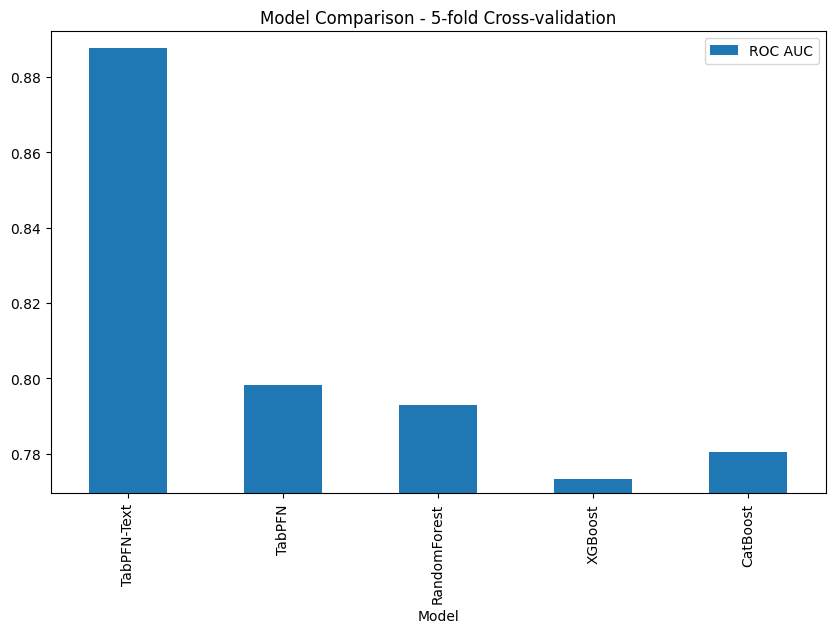

In [22]:
if backend == "client":
    # Encode target labels to classes for baselines
    le = LabelEncoder()
    y_text = le.fit_transform(y_text)

    # Define models
    models = [
        ("TabPFN-Text", TabPFNClassifier(random_state=42)),
        (
            "TabPFN",
            make_pipeline(
                column_transformer,  # string data needs to be encoded for model
                TabPFNClassifier(random_state=42),
            ),
        ),
        (
            "RandomForest",
            make_pipeline(
                column_transformer,  # string data needs to be encoded for model
                RandomForestClassifier(random_state=42),
            ),
        ),
        (
            "XGBoost",
            make_pipeline(
                column_transformer,  # string data needs to be encoded for model
                XGBClassifier(random_state=42),
            ),
        ),
        (
            "CatBoost",
            make_pipeline(
                column_transformer,  # string data needs to be encoded for model
                CatBoostClassifier(random_state=42, verbose=0),
            ),
        ),
    ]

    # Calculate scores
    cv = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)
    scoring = "roc_auc_ovr" if len(np.unique(y_text)) > 2 else "roc_auc"
    scores = {
        name: cross_val_score(
            model, X_text, y_text, cv=cv, scoring=scoring, n_jobs=1, verbose=1
        ).mean()
        for name, model in models
    }

    # Plot results
    df = pd.DataFrame(list(scores.items()), columns=["Model", "ROC AUC"])
    ax = df.plot(x="Model", y="ROC AUC", kind="bar", figsize=(10, 6))
    ax.set_ylim(df["ROC AUC"].min() * 0.995, min(1.0, df["ROC AUC"].max() * 1.005))
    ax.set_title("Model Comparison - 5-fold Cross-validation")

# Unsupervised Learning with TabPFN <a name="unsupervised-learning"></a>

TabPFN can also be used for unsupervised learning tasks like outlier detection and synthetic data generation. These features are available through the `tabpfn-extensions` library.


### Data Generation

In [23]:
from tabpfn_extensions import unsupervised

# Load and prepare breast cancer dataset
df = load_breast_cancer(return_X_y=False)
X, y = df["data"], df["target"]
feature_names = df["feature_names"]

# Initialize TabPFN models
model_unsupervised = unsupervised.TabPFNUnsupervisedModel(
    tabpfn_clf=TabPFNClassifier(), tabpfn_reg=TabPFNRegressor()
)

# Select features for synthetic data generation
# Example features: [mean texture, mean area, mean concavity]
feature_indices = [4, 6, 12]

# Run synthetic data generation experiment
experiment = unsupervised.experiments.GenerateSyntheticDataExperiment(
    task_type="unsupervised"
)

results = experiment.run(
    tabpfn=model_unsupervised,
    X=torch.tensor(X),
    y=torch.tensor(y),
    attribute_names=feature_names,
    temp=1.0,  # Temperature parameter for sampling
    n_samples=X.shape[0] * 2,  # Generate twice as many samples as original data
    indices=feature_indices,
)

  0%|          | 0/3 [00:03<?, ?it/s]


RuntimeError: Fail to call predict with error: {'detail': "Cannot return full output (logits and borders) for datasets with more than 500 samples for regression tasks. Current dataset has 1138 samples. Either reduce the number of samples or change the output_type to e.g. 'mean'."}

### Outlier detection

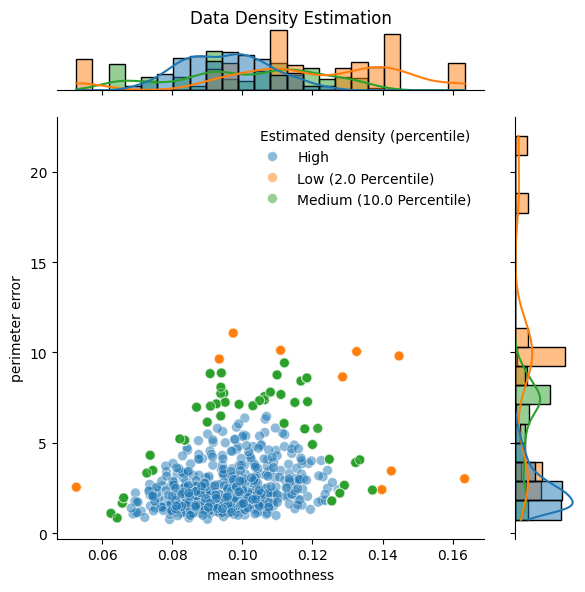

In [ ]:
import torch
from sklearn.datasets import load_breast_cancer
from tabpfn_extensions import unsupervised

# Load data
df = load_breast_cancer(return_X_y=False)
X, y = df["data"], df["target"]
attribute_names = df["feature_names"]

# Initialize models
clf = TabPFNClassifier(n_estimators=4)
reg = TabPFNRegressor(n_estimators=4)
model_unsupervised = unsupervised.TabPFNUnsupervisedModel(
    tabpfn_clf=clf, tabpfn_reg=reg
)

# Run outlier detection
exp_outlier = unsupervised.experiments.OutlierDetectionUnsupervisedExperiment(
    task_type="unsupervised"
)
results = exp_outlier.run(
    tabpfn=model_unsupervised,
    X=torch.tensor(X, dtype=torch.float32),
    y=torch.tensor(y),
    attribute_names=attribute_names,
    indices=[4, 12],  # Analyze features 4 and 12
)

### Missing value imputation

In [ ]:
# --- 1. Load and Prepare Data ---
# Load the breast cancer dataset
df = load_breast_cancer(return_X_y=False)
X, y = df["data"], df["target"]

# Split the data into training and testing sets
X_train, X_test = train_test_split(
    X,
    test_size=0.33,
    random_state=42,
)

# --- 2. Introduce Missing Values ---
# Create a copy of the test set to introduce missing values (NaNs)
X_test_missing = X_test.copy()
n_samples, n_features = X_test_missing.shape

# Introduce missing values in the first three columns for demonstration
missing_fraction = 0.3
n_missing = int(n_samples * missing_fraction)

for col_idx in range(3):
    # Choose random rows to set to NaN
    missing_indices = np.random.choice(n_samples, n_missing, replace=False)
    X_test_missing[missing_indices, col_idx] = np.nan

print(f"Introduced {np.isnan(X_test_missing).sum()} missing values into the test set.")
print(pd.DataFrame(X_test_missing[:, 0:3]).head())

# --- 3. Initialize the Unsupervised Model ---
# Initialize TabPFN models for regression and classification tasks.
# The unsupervised model uses these to model the data distribution.
clf = TabPFNClassifier(n_estimators=3)
reg = TabPFNRegressor(n_estimators=3)

# Initialize the main unsupervised model
model_unsupervised = unsupervised.TabPFNUnsupervisedModel(
    tabpfn_clf=clf,
    tabpfn_reg=reg,
)

# --- 4. Fit and Impute ---
# Fit the model on the complete training data (without missing values)
print("Fitting the unsupervised model on the training data...")
model_unsupervised.fit(X_train)

# Perform imputation on the test set
print("Imputing missing values...\n")
X_imputed_tensor = model_unsupervised.impute(
    X_test_missing,
    n_permutations=5,  # Fewer permutations for a quicker example
)

print("\n------------------------")

# --- 5. Verify Results ---
# Check that the imputed data no longer contains any NaN values
n_missing_after = torch.isnan(X_imputed_tensor).sum().item()

print(f"\nNumber of missing values after imputation: {n_missing_after}")
print(pd.DataFrame(X_imputed_tensor[:, 0:3]).head())

# Optional: Calculate the Mean Squared Error for the imputed values,
# since we know the original ground truth values.
original_nan_mask = np.isnan(X_test_missing)
imputed_values = X_imputed_tensor.numpy()[original_nan_mask]
original_values = X_test[original_nan_mask]

mse = np.mean((imputed_values - original_values) ** 2)
print(f"Mean Squared Error of imputed values vs. original values: {mse:.4f}")

Introduced 168 missing values into the test set.
       0      1       2
0  12.47  18.60     NaN
1  18.94    NaN  123.60
2  15.46  19.48  101.70
3    NaN  17.68   81.47
4  11.54  14.44   74.65
Fitting the unsupervised model on the training data...
Imputing missing values...



100%|██████████| 3/3 [00:12<00:00,  4.32s/it]


------------------------

Number of missing values after imputation: 0
           0          1           2
0  12.470000  18.600000   80.977982
1  18.940001  20.994347  123.599998
2  15.460000  19.480000  101.699997
3  12.455913  17.680000   81.470001
4  11.540000  14.440000   74.650002
Mean Squared Error of imputed values vs. original values: 1.7366


# Model Interpretability <a name="interpretability"></a>

Understanding *why* a model makes certain predictions is crucial for building trust and for debugging. The `tabpfn-extensions` library provides tools for model interpretability. We'll look at SHAP (SHapley Additive exPlanations) values, which show the impact of each feature on a specific prediction.

### Shapley Values

Next, we'll use SHAP to understand our model's predictions. SHAP values break down a prediction to show the contribution of each feature, helping us see which factors are most influential for a given data point.


PermutationExplainer explainer: 51it [03:00,  3.69s/it]


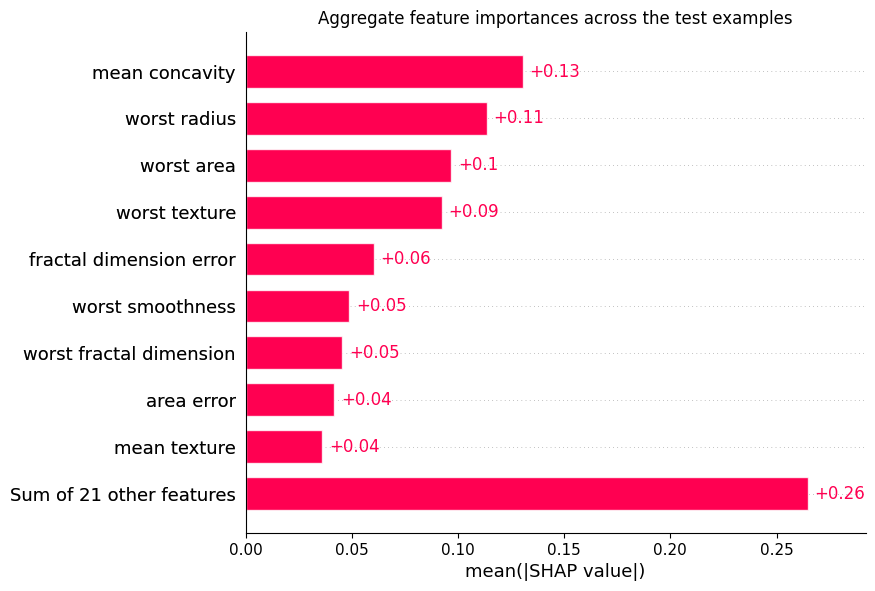

/content/tabpfn-extensions/src/tabpfn_extensions/interpretability/shap.py:134: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values=shap_values, show=False)


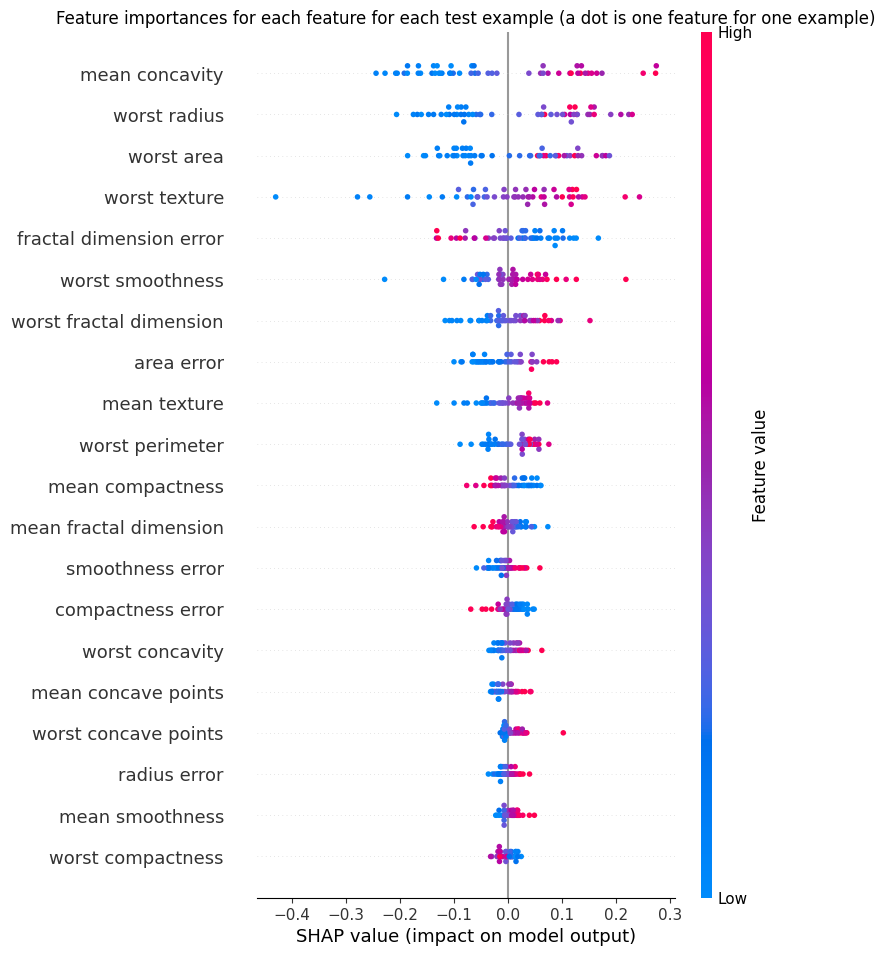

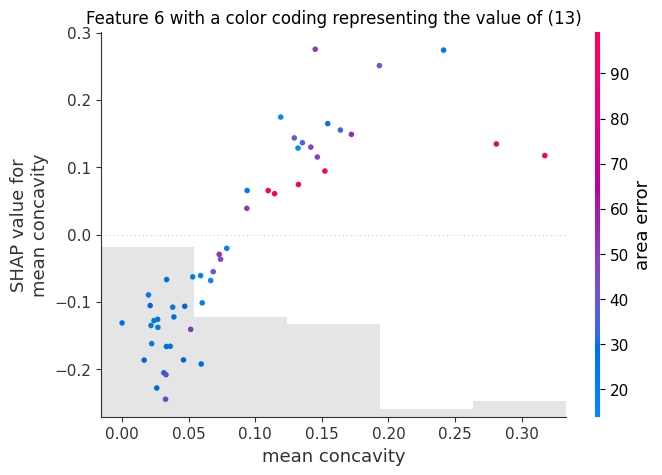

In [ ]:
from tabpfn_extensions import interpretability

# Load example dataset
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names
n_samples = 50

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

# Initialize and train model
clf = TabPFNClassifier()
clf.fit(X_train, y_train)

# Calculate SHAP values
shap_values = interpretability.shap.get_shap_values(
    estimator=clf,
    test_x=X_test[:n_samples],
    attribute_names=feature_names,
    algorithm="permutation",
)

# Create visualization
fig = interpretability.shap.plot_shap(shap_values)

### Embeddings

This example demonstrates how to extract embeddings from TabPFN models and use them
for classification and regression tasks.

NOTE: This example requires the full TabPFN implementation (pip install tabpfn).
It will not work with the TabPFN client (pip install tabpfn-client) because
the embedding functionality is not available in the client version.


Loading classification dataset (breast cancer)...
Baseline Logistic Regression Accuracy: 0.9614
Logistic Regression with TabPFN (Vanilla) Accuracy: 0.9825

Applying t-SNE for visualization on the TEST SET only...


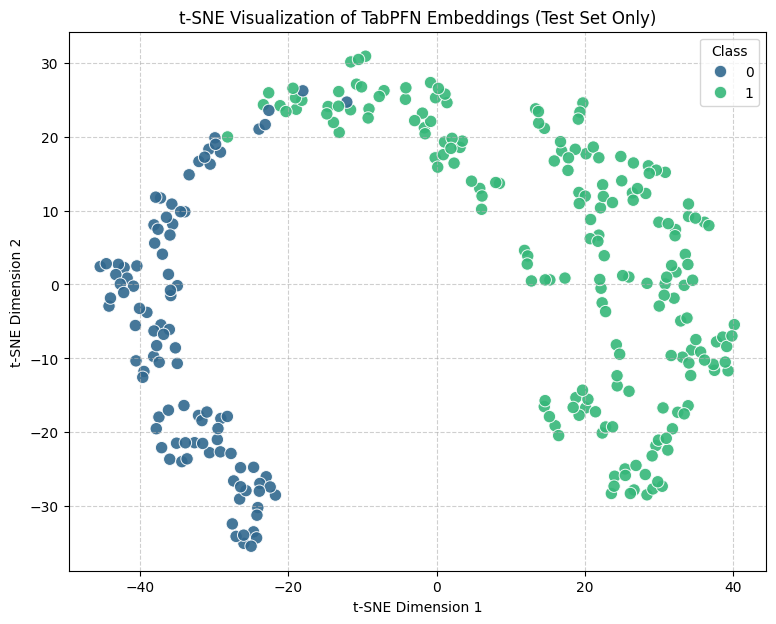

In [ ]:
if backend == "client":
    console.print(
        Panel(
            "[bold yellow]Text data can only be processed through the TabPFN server. Please restart the notebook and select the 'client' backend to run this section.[/bold yellow]",
            title="[bold yellow]Warning",
            border_style="yellow",
        )
    )
else:
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import seaborn as sns
    from sklearn.datasets import load_breast_cancer, load_diabetes
    from sklearn.linear_model import LinearRegression, LogisticRegression
    from sklearn.manifold import TSNE
    from sklearn.metrics import accuracy_score, r2_score
    from sklearn.model_selection import train_test_split
    from tabpfn_extensions import TabPFNClassifier, TabPFNRegressor
    from tabpfn_extensions.embedding import TabPFNEmbedding

    # Load and evaluate classification dataset
    print("Loading classification dataset (breast cancer)...")
    df = load_breast_cancer(return_X_y=False)
    X, y = df["data"], df["target"]
    attribute_names = df["feature_names"]

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.5,
        random_state=42,
    )

    # Train and evaluate vanilla logistic regression
    model = LogisticRegression(
        max_iter=10000,
        random_state=42,
    )
    model.fit(X_train, y_train)
    print(
        f"Baseline Logistic Regression Accuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}",
    )

    # Train and evaluate TabPFN embeddings (vanilla)
    clf = TabPFNClassifier(n_estimators=1, random_state=42)
    embedding_extractor = TabPFNEmbedding(tabpfn_clf=clf, n_fold=0)
    train_embeddings = embedding_extractor.get_embeddings(
        X_train,
        y_train,
        X_test,
        data_source="train",
    )
    test_embeddings = embedding_extractor.get_embeddings(
        X_train,
        y_train,
        X_test,
        data_source="test",
    )

    model = LogisticRegression(
        max_iter=10000,
        random_state=42,
    )
    model.fit(train_embeddings[0], y_train)
    y_pred = model.predict(test_embeddings[0])
    print(
        f"Logistic Regression with TabPFN (Vanilla) Accuracy: {accuracy_score(y_test, y_pred):.4f}",
    )

    # Note: Using test_embeddings and y_test from your original script.
    # The embeddings have shape (n_splits, n_samples, n_features), so we use the first split [0].
    test_only_embeddings = test_embeddings[0]

    # Apply t-SNE to reduce the TEST embeddings to 2 dimensions.
    # The number of samples in the test set is len(y_test). Perplexity must be less than that.
    # We'll set perplexity to 30, which is suitable for this dataset size.
    print("\nApplying t-SNE for visualization on the TEST SET only...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=10)
    embeddings_2d = tsne.fit_transform(test_only_embeddings)

    # Create a DataFrame for easy plotting
    df_plot = pd.DataFrame(
        {
            "t-SNE-1": embeddings_2d[:, 0],
            "t-SNE-2": embeddings_2d[:, 1],
            "label": y_test,
        }
    )

    # Plot the 2D embeddings for the test set
    plt.figure(figsize=(9, 7))
    sns.scatterplot(
        data=df_plot,
        x="t-SNE-1",
        y="t-SNE-2",
        hue="label",  # Color points by their class label
        palette="viridis",
        alpha=0.9,
        s=80,
    )

    plt.title("t-SNE Visualization of TabPFN Embeddings (Test Set Only)")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend(title="Class")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

### Feature selection

Feature selection is the process of selecting a subset of relevant features for use in model construction. It's useful for reducing model complexity, improving performance by removing noise, and decreasing training time. Here, we'll use Sequential Forward Selection (SFS), which starts with no features and iteratively adds the feature that most improves the model's performance.

The goal is to see if we can create a simpler, faster model with fewer features without a significant drop in accuracy.


In [ ]:
from tabpfn_extensions import interpretability

# Load data
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

# Initialize model
clf = TabPFNClassifier(n_estimators=1)

# Feature selection
sfs = interpretability.feature_selection.feature_selection(
    estimator=clf, X=X, y=y, n_features_to_select=4, feature_names=feature_names
)

# Print selected features
selected_features = [
    feature_names[i] for i in range(len(feature_names)) if sfs.get_support()[i]
]
print("\nSelected features:")
for feature in selected_features:
    print(f"- {feature}")


Selected features:
- mean texture
- mean concavity
- worst perimeter
- worst smoothness


# Predictive Behavior of TabPFN <a name="behavior"></a>

In this section, we explore the behavior of predictions from TabPFN on various toy functions.

## Decision Boundary during Classification

First, let us inspect the decision boundary for different classifiers.
The decision bounds show how smoothly a model learns to transition between classes and how well it fits the data.

In the first cell, we create the data and code to plot the decision boundary. The second cell then generates the plot.

In [ ]:
from matplotlib.colors import ListedColormap
from sklearn.inspection import DecisionBoundaryDisplay


# Toy functions that generate the data
def generate_circle(n_datapoints, radius, noise_factor):
    angles = np.linspace(0, 2 * np.pi, n_datapoints).T
    x = radius * np.cos(angles) + np.random.randn(n_datapoints) * noise_factor
    y = radius * np.sin(angles) + np.random.randn(n_datapoints) * noise_factor

    return np.stack([x, y]).T


def generate_concentric_cirlces(radii, num_points_per_circle, noise_factor=1 / 15):
    circles = []
    for r, num_points in zip(radii, num_points_per_circle):
        circles.append(generate_circle(num_points, r, noise_factor))

    return np.vstack(circles)


def generate_circle_data(num_points_per_circle, radii, noise_factor):
    radii = np.array(radii)
    circles_1 = generate_concentric_cirlces(radii, num_points_per_circle, noise_factor)
    circles_1 = np.hstack([circles_1, np.zeros((sum(num_points_per_circle), 1))])

    circles_2 = generate_concentric_cirlces(
        radii + 0.3, num_points_per_circle, noise_factor
    )
    circles_2 = np.hstack([circles_2, np.ones((sum(num_points_per_circle), 1))])

    circles = np.vstack([circles_1, circles_2])
    X, y = circles[:, :2], circles[:, 2]
    return X, y


# Generate the data
X_train, y_train = generate_circle_data(
    num_points_per_circle=[50, 100, 200], radii=[1, 2, 4], noise_factor=0.1
)


# Function for plotting
def plot_decision_boundary(ax, model, model_name):
    cmap = ListedColormap(["#FF0000", "#0000FF"])
    ax.set_title(model_name)
    DecisionBoundaryDisplay.from_estimator(
        model,
        X_train[:, :2],
        alpha=0.6,
        ax=ax,
        eps=0.2,
        grid_resolution=50,
        response_method="predict_proba",
        cmap=plt.cm.RdBu,
    )
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train > 0, cmap=cmap)

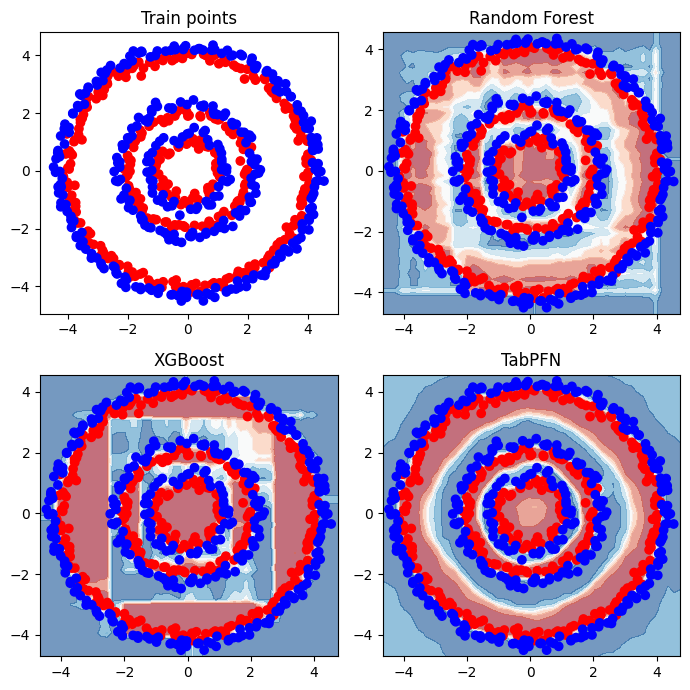

In [ ]:
rf = RandomForestClassifier().fit(X_train[:, :2], y_train)
xgb = XGBClassifier().fit(X_train[:, :2], y_train)
tabpfn = TabPFNClassifier().fit(X_train[:, :2], y_train)

# Create a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(7, 7))

# Plot Train Points
ax_points = axes[0, 0]
ax_points.set_title("Train points")
ax_points.scatter(
    X_train[:, 0], X_train[:, 1], c=y_train, cmap=ListedColormap(["#FF0000", "#0000FF"])
)

# Plot Random Forest
ax_rf = axes[0, 1]
plot_decision_boundary(ax_rf, rf, "Random Forest")

# Plot XGBoost
ax_xgb = axes[1, 0]
plot_decision_boundary(ax_xgb, xgb, "XGBoost")

# Plot TabPFN
ax_tabpfn = axes[1, 1]
plot_decision_boundary(ax_tabpfn, tabpfn, "TabPFN")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

## Sin Curve Fitting with Regression

Next, we investigate the curve-fitting behavior of the different models on a sin curve.

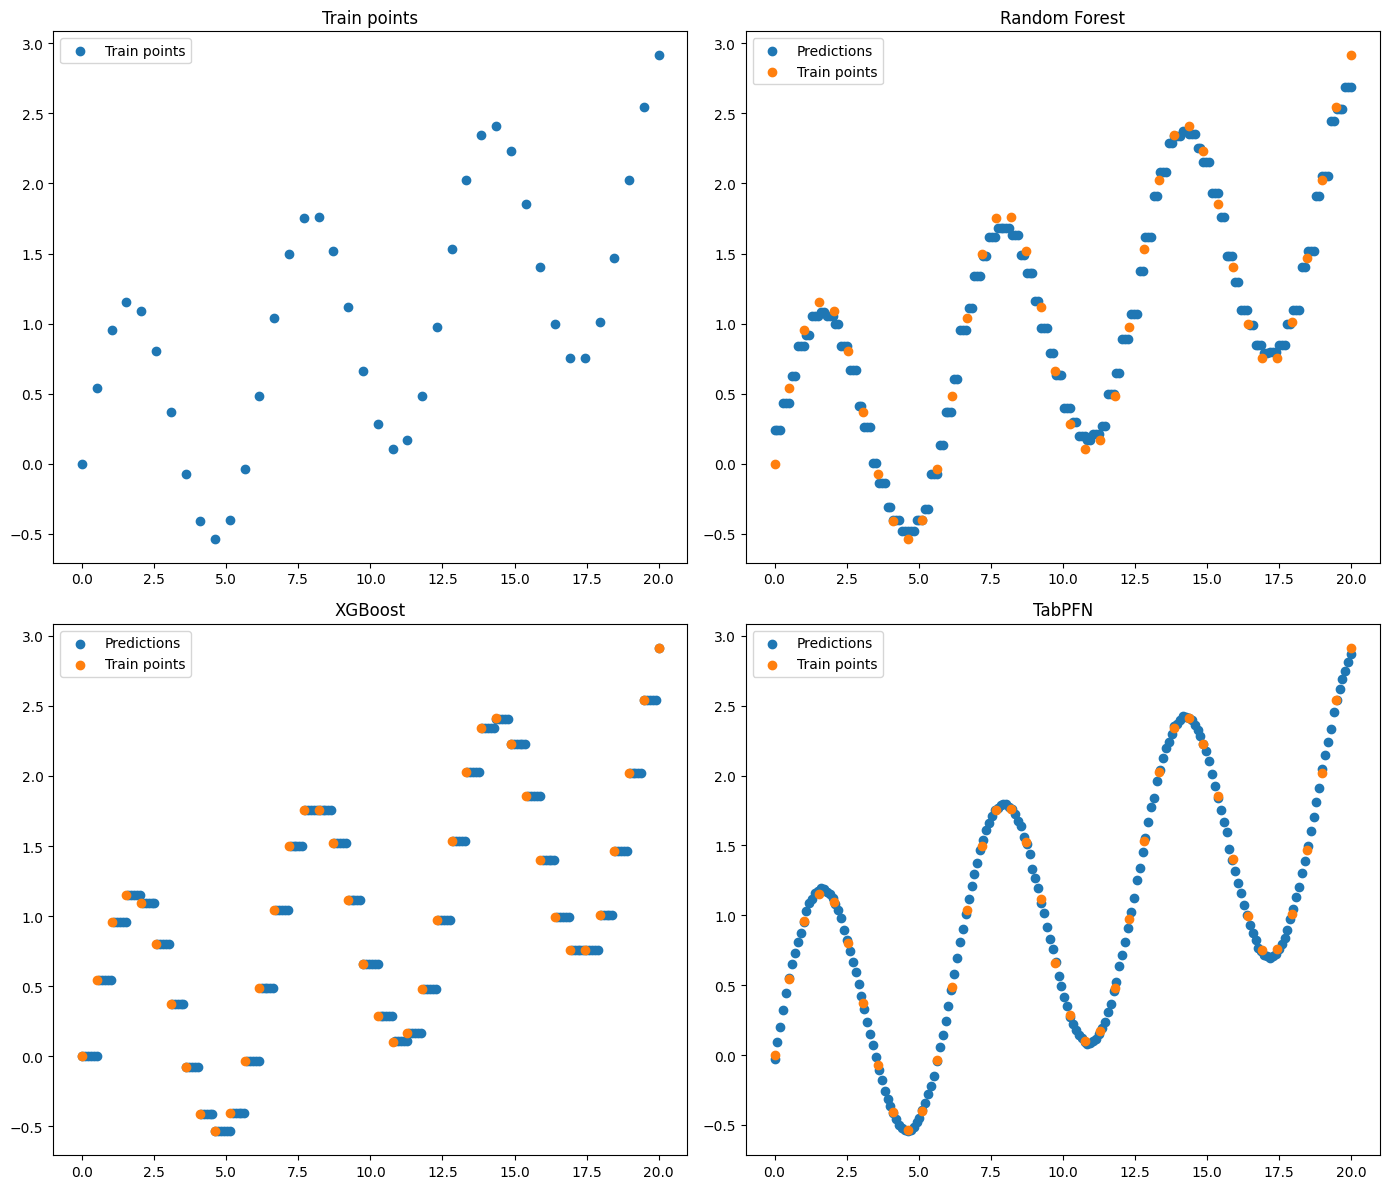

In [ ]:
# Toy function to generate data
def generate_sinx_plus_x(N):
    x = np.linspace(0, 20, N)
    y = np.sin(x) + x / 10

    return x.reshape(-1, 1), y


# Utility function for plotting
def plot_predictions(ax, model, model_name):
    X_test = np.linspace(0, 20, 200).reshape(
        -1, 1
    )  # Predict for 200 points  between 0 and 20
    y_preds = model.predict(X_test)
    ax.set_title(model_name)
    ax.scatter(X_test, y_preds, label="Predictions")
    ax.scatter(X_train, y_train, label="Train points")
    ax.legend()


# Generate data
X_train, y_train = generate_sinx_plus_x(N=40)

# Fit Models
rf = RandomForestRegressor(random_state=42).fit(X_train, y_train)
xgb = XGBRegressor(random_state=42).fit(X_train, y_train)
tabpfn = TabPFNRegressor()
tabpfn.fit(X_train, y_train)

# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Plot train points
ax_points = axs[0, 0]
ax_points.set_title("Train points")
ax_points.scatter(X_train, y_train, label="Train points")
ax_points.legend()

# Plot predictions for Random Forest
ax_rf = axs[0, 1]
plot_predictions(ax_rf, rf, "Random Forest")

# Plot predictions for XGBoost
ax_xgb = axs[1, 0]
plot_predictions(ax_xgb, xgb, "XGBoost")

# Plot predictions for TabPFN
ax_tabpfn = axs[1, 1]
plot_predictions(ax_tabpfn, tabpfn, "TabPFN")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

## Uncertainty of TabPFN / Quantile Regresison

---



TabPFN is trained to predict the distribution of the target variable and not just a single point. This is also the case for regression.

As a result, we natively obtain uncertainty for the predictions of TabPFN (without the need for a new model or repeating models for different quantiles).

In the following, we plot the uncertainty of TabPFN for a toy function with noise.

In [ ]:
### Code to generate the plot (feel free to ignore)
def plot_regression_uncertainty(ax, x, y_line, y_noisy, x_test, color_multiplier=5):
    all_quantiles = preds["quantiles"]
    y = np.array(all_quantiles)  # shape of y: (9, number of samples)

    # Calculate the maximum and minimum values in y
    y_max = np.max(y, axis=0)
    y_min = np.min(y, axis=0)

    # Calculate the widths of each quantile bin
    quantile_bin_widths = np.diff(
        y, axis=0
    )  # shape of quantile_bin_widths: (8, number of samples)

    # Normalize the bin widths for a given x
    per_x_normalized_bin_widths = (quantile_bin_widths) / (y_max - y_min)

    # Plotting
    num_bins, num_data_points = (
        per_x_normalized_bin_widths.shape[0],
        per_x_normalized_bin_widths.shape[1],
    )
    rect_width = (
        x_test[1] - x_test[0]
    ).squeeze()  # assuming the x query points are equally spaced out

    for i in range(num_data_points):
        for j in range(num_bins):
            quantile_bin_widths[j, i]
            rect = plt.Rectangle(
                xy=(x_test[i][0] - rect_width / 2, y[j, i]),
                width=rect_width,
                height=quantile_bin_widths[j, i],
                facecolor=plt.cm.viridis(
                    per_x_normalized_bin_widths[j, i] * color_multiplier
                ),
                edgecolor="none",
            )
            ax.add_patch(rect)

    # Set limits and labels
    ax.plot(x, y_line, label="True line", color="blue")
    ax.set_xlim(min(x_test) - 1, max(x_test) + 1)
    ax.set_ylim(np.min(y_noisy) - 1, np.max(y_noisy) + 1)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

    # ax.plot(x, y, label='True line', color='blue')
    ax.scatter(x, y_noisy, label="Noisy data", color="red", s=10)

    plt.title("TabPFN Regression Uncertainty")
    plt.show()


# Generate Data
def generate_line_with_heteroscedastic_noise(
    m=0.8, num_points=200, x_start=0, x_end=100, noise_factor=0.1
):
    x = np.linspace(x_start, x_end, num_points)
    noise = np.random.randn(num_points)
    y = m * x
    y_noisy = y + (noise * noise_factor * x)

    return x.reshape(-1, 1), y, y_noisy


def generate_line_with_heteroscedastic_noise_with_gap(
    m=0.8, num_points=200, x_start=0, x_end=100, noise_factor=0.1
):
    extra_points = num_points // 3
    x, y, y_noisy = generate_line_with_heteroscedastic_noise(
        m, num_points + extra_points, x_start, x_end, noise_factor
    )
    a = np.arange(num_points + extra_points)
    idx = np.where((a < num_points / 3) | (a > num_points / 3 + extra_points))
    return x[idx], y[idx], y_noisy[idx]


x, y_line, y_noisy = generate_line_with_heteroscedastic_noise_with_gap(0.8)
x_test = np.linspace(0, 100, 200).reshape(-1, 1)

In [ ]:
reg = TabPFNRegressor()
reg.fit(x, y_noisy)
preds = reg.predict(x_test, output_type="full")

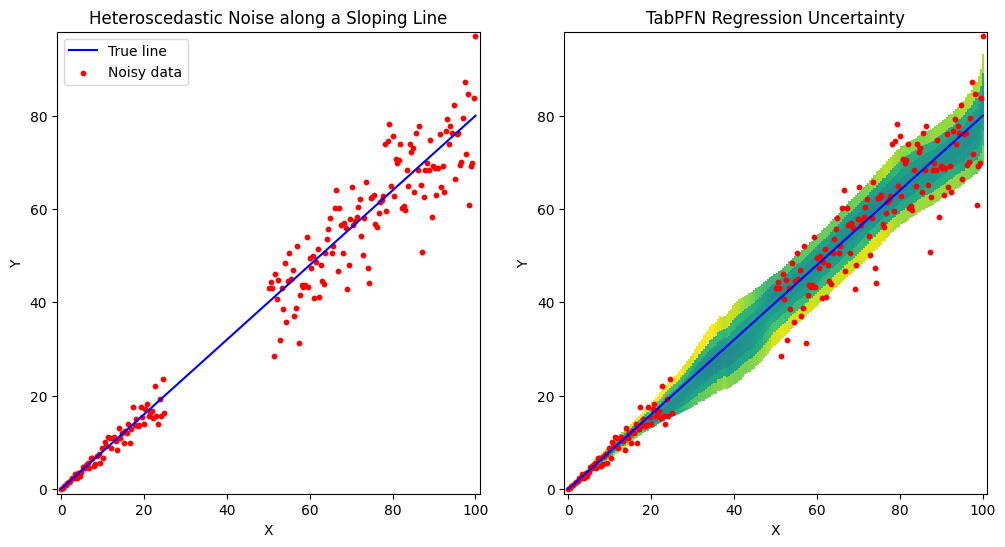

In [ ]:
fig = plt.figure(figsize=(12, 6))

# Plot the original data
ax = fig.add_subplot(121)
ax.plot(x, y_line, label="True line", color="blue")
ax.scatter(x, y_noisy, label="Noisy data", color="red", s=10)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_xlim(min(x) - 1, max(x) + 1)
ax.set_ylim(np.min(y_noisy) - 1, np.max(y_noisy) + 1)
ax.set_title("Heteroscedastic Noise along a Sloping Line")
ax.legend()

# plot the uncertainty estimates obtained from TabPFN
ax = fig.add_subplot(122)
plot_regression_uncertainty(ax, x, y_line, y_noisy, x_test, color_multiplier=5)

# Time Series Forecasting <a name="timeseries"></a>

TabPFN can be used for time series prediction, following the work of Hoo et al. (Zero-Shot Time Series Forecasting with TabPFNv2; https://arxiv.org/abs/2501.02945v3).

In this demo, we will use the time series dataset from [Chronos Dataset](https://huggingface.co/datasets/autogluon/chronos_datasets) on HuggingFace. Also, we'll keep it short and work with just 2 time series from the dataset.

Feel free to explore other datasets by using the dataset names from Chronos Dataset on HuggingFace or even use time series data of your own problem.


## *Installation*

In [ ]:
!uv pip install tabpfn-time-series
raise ValueError("Make sure to restart the session before proceeding, otherwise errors will follow (Runtime > Restart Session)")

Using Python 3.11.13 environment at: /usr
Resolved 60 packages in 505ms
⠙ Preparing packages... (0/4)
⠙ Preparing packages... (0/4)
⠙ Preparing packages... (0/4)
⠙ Preparing packages... (0/4)
⠙ Preparing packages... (0/4)
⠙ Preparing packages... (0/4)
pandas     ------------------------------     0 B/11.67 MiB
⠙ Preparing packages... (0/4)
gluonts    ------------------------------     0 B/1.45 MiB
pandas     ------------------------------     0 B/11.67 MiB
⠙ Preparing packages... (0/4)
tabpfn-time-series ------------------------------     0 B/32.56 KiB
gluonts    ------------------------------     0 B/1.45 MiB
pandas     ------------------------------     0 B/11.67 MiB
⠙ Preparing packages... (0/4)
tabpfn-time-series ------------------------------     0 B/32.56 KiB
gluonts    ------------------------------ 16.00 KiB/1.45 MiB
pandas     ------------------------------     0 B/11.67 MiB
⠙ Preparing packages... (0/4)
tabpfn-time-series ------------------------------     0 B/32.56 KiB
gluon

## Load Time Series Data

In this demo, we will use the time series dataset from [Chronos Dataset](https://huggingface.co/datasets/autogluon/chronos_datasets) on HuggingFace. Also, we'll keep it short and work with just 2 time series from the dataset.

Feel free to explore other datasets by using the dataset names from Chronos Dataset on HuggingFace or even use time series data of your own problem.

In [ ]:
dataset_metadata = {
    "monash_tourism_monthly": {"prediction_length": 24},
    "m4_hourly": {"prediction_length": 48},
}

dataset_choice = "monash_tourism_monthly"
num_time_series_subset = 2

In [ ]:
from datasets import load_dataset
from tabpfn_time_series import TimeSeriesDataFrame
from tabpfn_time_series.data_preparation import generate_test_X, to_gluonts_univariate

prediction_length = dataset_metadata[dataset_choice]["prediction_length"]
dataset = load_dataset("autogluon/chronos_datasets", dataset_choice)

tsdf = TimeSeriesDataFrame(to_gluonts_univariate(dataset["train"]))
tsdf = tsdf[
    tsdf.index.get_level_values("item_id").isin(tsdf.item_ids[:num_time_series_subset])
]
train_tsdf, test_tsdf_ground_truth = tsdf.train_test_split(
    prediction_length=prediction_length
)
test_tsdf = generate_test_X(train_tsdf, prediction_length)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Let's take a look at the time series data.

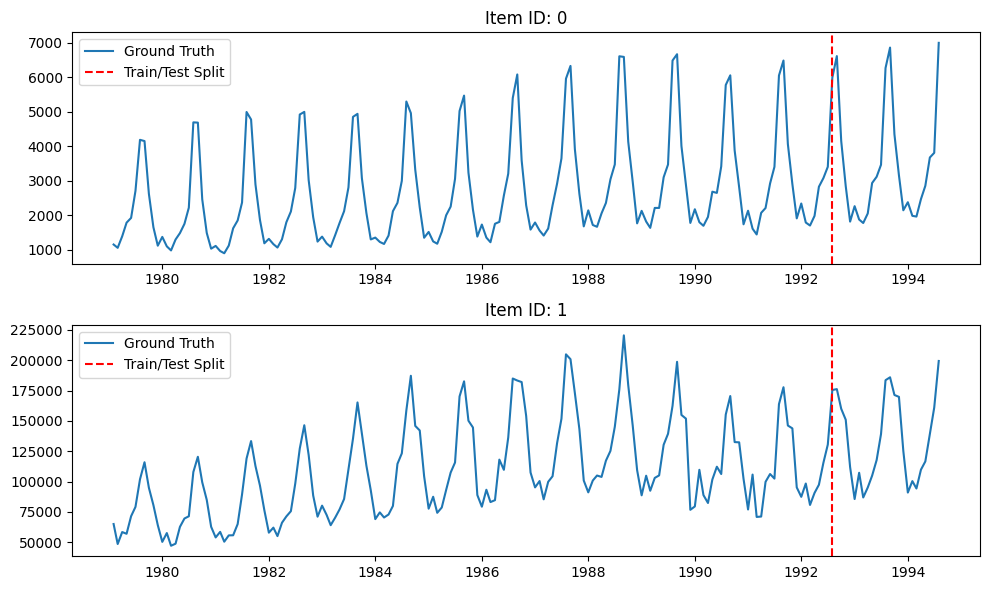

In [ ]:
from tabpfn_time_series.plot import plot_actual_ts

plot_actual_ts(train_tsdf, test_tsdf_ground_truth)

## Adding Features

In our paper, we propose adding `Running Index`, `Calendar Features`, and `Auto Seasonal Features` to the table.

**Feel free to experiment with your own features!**

To do that, simply define your own feature functions and pass them to the `FeatureTransformer`.

In [ ]:
from tabpfn_time_series import FeatureTransformer
from tabpfn_time_series.features import (
    AutoSeasonalFeature,
    CalendarFeature,
    RunningIndexFeature,
)

selected_features = [
    RunningIndexFeature(),
    CalendarFeature(),
    AutoSeasonalFeature(),
]

feature_transformer = FeatureTransformer(selected_features)

train_tsdf, test_tsdf = feature_transformer.transform(train_tsdf, test_tsdf)

Let's take a look at the tables (train and test) before we proceed to do predictions.

✅ Realize that we have added some features into the tables.

In [ ]:
train_tsdf.head()

target  running_index  year  second_of_minute_sin  \
item_id timestamp                                                          
0       1979-01-31  1149.8700              0  1979                   0.0   
        1979-02-28  1053.8002              1  1979                   0.0   
        1979-03-31  1388.8798              2  1979                   0.0   
        1979-04-30  1783.3702              3  1979                   0.0   
        1979-05-31  1921.0252              4  1979                   0.0   

                    second_of_minute_cos  minute_of_hour_sin  \
item_id timestamp                                              
0       1979-01-31                   1.0                 0.0   
        1979-02-28                   1.0                 0.0   
        1979-03-31                   1.0                 0.0   
        1979-04-30                   1.0                 0.0   
        1979-05-31                   1.0                 0.0   

                    minute_of_hour_cos  hour_of_day_sin  hour_of_day_cos  \
item_id timestamp                                                          
0       1979-01-31                 1.0              0.0              1.0   
        1979-02-28                 1.0              0.0              1.0   
        1979-03-31                 1.0              0.0              1.0   
        1979-04-30                 1.0              0.0              1.0   
        1979-05-31                 1.0              0.0              1.0   

                    day_of_week_sin  ...    sin_#0        cos_#0  \
item_id timestamp                    ...                           
0       1979-01-31     8.660254e-01  ...  0.000000  1.000000e+00   
        1979-02-28     8.660254e-01  ...  0.500000  8.660254e-01   
        1979-03-31    -8.660254e-01  ...  0.866025  5.000000e-01   
        1979-04-30     0.000000e+00  ...  1.000000  6.123234e-17   
        1979-05-31     1.224647e-16  ...  0.866025 -5.000000e-01   

                          sin_#1  cos_#1        sin_#2        cos_#2  \
item_id timestamp                                                      
0       1979-01-31  0.000000e+00     1.0  0.000000e+00  1.000000e+00   
        1979-02-28  8.660254e-01     0.5  1.000000e+00  6.123234e-17   
        1979-03-31  8.660254e-01    -0.5  1.224647e-16 -1.000000e+00   
        1979-04-30  1.224647e-16    -1.0 -1.000000e+00 -1.836970e-16   
        1979-05-31 -8.660254e-01    -0.5 -2.449294e-16  1.000000e+00   

                          sin_#3  cos_#3        sin_#4  cos_#4  
item_id timestamp                                               
0       1979-01-31  0.000000e+00     1.0  0.000000e+00     1.0  
        1979-02-28  1.224647e-16    -1.0  8.660254e-01    -0.5  
        1979-03-31 -2.449294e-16     1.0 -8.660254e-01    -0.5  
        1979-04-30  3.673940e-16    -1.0 -2.449294e-16     1.0  
        1979-05-31 -4.898587e-16     1.0  8.660254e-01    -0.5  

[5 rows x 29 columns]

In [ ]:
test_tsdf.head()

target  running_index  year  second_of_minute_sin  \
item_id timestamp                                                       
0       1992-08-31     NaN            163  1992                   0.0   
        1992-09-30     NaN            164  1992                   0.0   
        1992-10-31     NaN            165  1992                   0.0   
        1992-11-30     NaN            166  1992                   0.0   
        1992-12-31     NaN            167  1992                   0.0   

                    second_of_minute_cos  minute_of_hour_sin  \
item_id timestamp                                              
0       1992-08-31                   1.0                 0.0   
        1992-09-30                   1.0                 0.0   
        1992-10-31                   1.0                 0.0   
        1992-11-30                   1.0                 0.0   
        1992-12-31                   1.0                 0.0   

                    minute_of_hour_cos  hour_of_day_sin  hour_of_day_cos  \
item_id timestamp                                                          
0       1992-08-31                 1.0              0.0              1.0   
        1992-09-30                 1.0              0.0              1.0   
        1992-10-31                 1.0              0.0              1.0   
        1992-11-30                 1.0              0.0              1.0   
        1992-12-31                 1.0              0.0              1.0   

                    day_of_week_sin  ...    sin_#0        cos_#0  \
item_id timestamp                    ...                           
0       1992-08-31     0.000000e+00  ... -0.500000 -8.660254e-01   
        1992-09-30     8.660254e-01  ... -0.866025 -5.000000e-01   
        1992-10-31    -8.660254e-01  ... -1.000000 -1.224956e-14   
        1992-11-30     0.000000e+00  ... -0.866025  5.000000e-01   
        1992-12-31     1.224647e-16  ... -0.500000  8.660254e-01   

                          sin_#1  cos_#1        sin_#2        cos_#2  \
item_id timestamp                                                      
0       1992-08-31  8.660254e-01     0.5 -1.000000e+00 -2.596808e-14   
        1992-09-30  8.660254e-01    -0.5 -3.135839e-14  1.000000e+00   
        1992-10-31  2.449913e-14    -1.0  1.000000e+00  3.674869e-14   
        1992-11-30 -8.660254e-01    -0.5 -1.470443e-14 -1.000000e+00   
        1992-12-31 -8.660254e-01     0.5 -1.000000e+00  9.314124e-15   

                          sin_#3  cos_#3        sin_#4  cos_#4  
item_id timestamp                                               
0       1992-08-31  5.193617e-14    -1.0  8.660254e-01    -0.5  
        1992-09-30 -6.271677e-14     1.0 -8.660254e-01    -0.5  
        1992-10-31  7.349738e-14    -1.0 -4.899825e-14     1.0  
        1992-11-30  2.940885e-14     1.0  8.660254e-01    -0.5  
        1992-12-31 -1.862825e-14    -1.0 -8.660254e-01    -0.5  

[5 rows x 29 columns]

## Prediction

Now, let's perform prediction.

We provide two options, `TabPFNMode.LOCAL` and `TabPFNMode.CLIENT`, as the backend for TabPFN.

- `TabPFNMode.LOCAL` uses your local machine to run TabPFN.
- `TabPFNMode.CLIENT` uses TabPFN's inference service provided by [tabpfn-client](https://github.com/automl/tabpfn-client)

For this demo, we'll use `TabPFNMode.CLIENT` to perform prediction. If you have not use the client before, you'll be prompted to create an account.

Note: if your machine doesn't have a GPU, using `TabPFNMode.CLIENT` is recommended -- must faster 😉.


In [ ]:
from tabpfn_time_series import TabPFNMode, TabPFNTimeSeriesPredictor

predictor = TabPFNTimeSeriesPredictor(
    tabpfn_mode=TabPFNMode.LOCAL,  # adapt this to TabPFNMode.CLIENT if using API
)

pred = predictor.predict(train_tsdf, test_tsdf)

tabpfn-v2-regressor-2noar4o2.ckpt:   0%|          | 0.00/44.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

## Visualize the Results

Let's visualize the forecasting results.

Also, note that we provide both **point prediction** and **quantile prediction**, how amazing! 😄

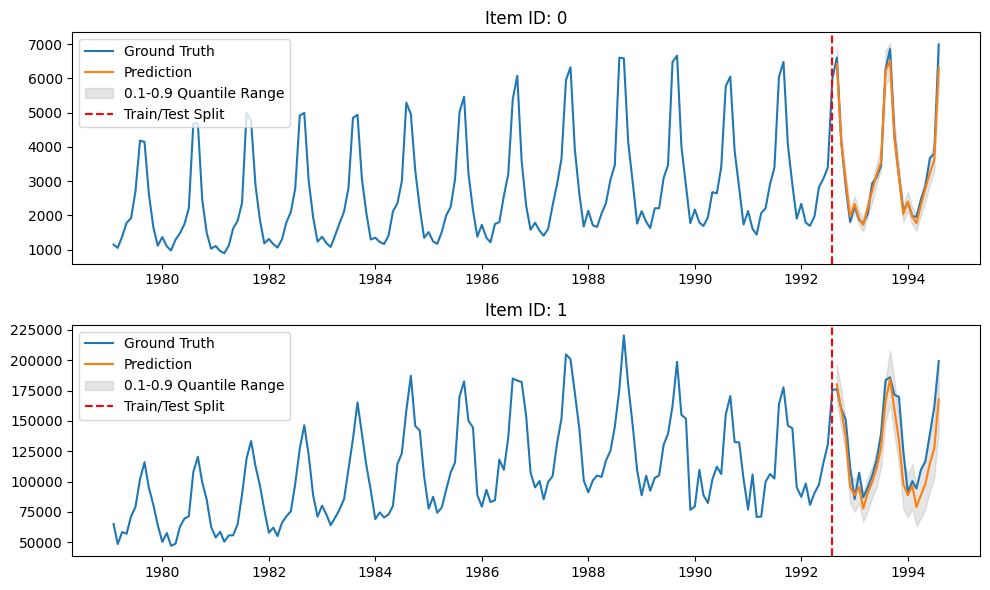

In [ ]:
from tabpfn_time_series.plot import plot_pred_and_actual_ts

plot_pred_and_actual_ts(
    train=train_tsdf,
    test=test_tsdf_ground_truth,
    pred=pred,
)

In [ ]:
pred.head()

target          0.1          0.2          0.3  \
item_id timestamp                                                        
0       1992-08-31  6426.939453  6031.653320  6178.973145  6275.490234   
        1992-09-30  4145.877441  3876.051514  3968.562012  4035.613037   
        1992-10-31  3011.042725  2784.187012  2865.281006  2921.160889   
        1992-11-30  1973.286865  1771.009521  1840.910278  1890.718872   
        1992-12-31  2334.358643  2097.147949  2181.239014  2240.146484   

                            0.4          0.5          0.6          0.7  \
item_id timestamp                                                        
0       1992-08-31  6353.638184  6426.939453  6504.241699  6594.743652   
        1992-09-30  4092.619629  4145.877441  4200.451172  4261.462402   
        1992-10-31  2967.819336  3011.042725  3053.839844  3101.681396   
        1992-11-30  1933.383545  1973.286865  2014.023560  2059.214111   
        1992-12-31  2289.293945  2334.358643  2378.629883  2425.561279   

                            0.8          0.9  
item_id timestamp                             
0       1992-08-31  6715.722168  6915.344238  
        1992-09-30  4340.528809  4468.440918  
        1992-10-31  3160.598389  3250.026367  
        1992-11-30  2114.486328  2196.697754  
        1992-12-31  2480.219238  2554.438477

# Feedback

Let us know what you think!

Write us at Discord: https://discord.gg/qK7AaXPN or just simply create an issue on [GitHub](https://github.com/PriorLabs/tabpfn).

Thank you for trying out our method! 🎉
